In [1]:
import sys
print(sys.version)
print(sys.executable)

3.10.20 (main, Mar 11 2026, 17:46:40) [GCC 14.3.0]
/home/mack-pol/miniconda3/envs/cudaq-env/bin/python


In [2]:
# This cell is added by sphinx-gallery
# It can be customized to whatever you like
%matplotlib inline

In [3]:
import numpy as np
import pennylane as qml

In [4]:
# ============================================================================
# STEP 1: LOAD H₂O MOLECULAR DATA (Fixed for PennyLane)
# ============================================================================

import os
import numpy as np
import pandas as pd
import torch
import pickle
import json
import matplotlib.pyplot as plt
import pennylane as qml
from pennylane import qchem

# Create results directory for H₂O
RESULTS_DIR = "./results/H2O"
os.makedirs(RESULTS_DIR, exist_ok=True)

print("="*80)
print("STEP 1: LOADING H₂O MOLECULAR DATA")
print("="*80)

def generate_molecule_data(molecules="H2O"):
    datasets = qml.data.load("qchem", molname=molecules)

    # Get the time set T
    op_times = np.sort(np.array([-2**k for k in range(1, 5)] + [2**k for k in range(1, 5)]) / 160)

    # Build operator set P for each molecule
    molecule_data = dict()
    for dataset in datasets:
        molecule = dataset.molecule
        num_electrons, num_qubits = molecule.n_electrons, 2 * molecule.n_orbitals
        singles, doubles = qml.qchem.excitations(num_electrons, num_qubits)
        double_excs = [qml.DoubleExcitation(time, wires=double) for double in doubles for time in op_times]
        single_excs = [qml.SingleExcitation(time, wires=single) for single in singles for time in op_times]
        identity_ops = [qml.exp(qml.Identity(wires=range(num_qubits)), 1j*time) for time in op_times]
        operator_pool = double_excs + single_excs + identity_ops
        
        # Get HF energy from molecule attributes if available
        hf_energy = getattr(molecule, 'hf_energy', None)
        if hf_energy is None:
            hf_energy = 0.0  # Placeholder if not available
        
        molecule_data[dataset.molname] = {
            "op_pool": np.array(operator_pool), 
            "num_qubits": int(num_qubits),
            "hf_state": dataset.hf_state,
            "hamiltonian": dataset.hamiltonian,
            "expected_ground_state_E": float(dataset.fci_energy),
            "num_electrons": int(num_electrons),
            "n_orbitals": int(molecule.n_orbitals),
            "hf_energy": float(hf_energy) if hf_energy else 0.0,
        }
    return molecule_data

# Load H₂O data
print("Loading H₂O data from PennyLane...")
molecule_data = generate_molecule_data("H2O")
h2o_data = molecule_data["H2O"]

# Extract variables
op_pool = h2o_data["op_pool"]
num_qubits = h2o_data["num_qubits"]
init_state = h2o_data["hf_state"]
hamiltonian = h2o_data["hamiltonian"]
grd_E = h2o_data["expected_ground_state_E"]
op_pool_size = len(op_pool)
num_electrons = h2o_data["num_electrons"]
n_orbitals = h2o_data["n_orbitals"]
hf_energy = h2o_data["hf_energy"]

print(f"\n✓ H₂O Data Loaded Successfully")
print(f"  Molecule: H₂O")
print(f"  Number of qubits: {num_qubits}")
print(f"  Number of electrons: {num_electrons}")
print(f"  Number of orbitals: {n_orbitals}")
print(f"  Operator pool size: {op_pool_size}")
print(f"  HF energy: {hf_energy:.8f} Ha" if hf_energy else "  HF energy: Not available")
print(f"  FCI energy (ground state): {grd_E:.8f} Ha")

# Save molecule data as pickle
with open(os.path.join(RESULTS_DIR, "molecule_data.pkl"), "wb") as f:
    pickle.dump(h2o_data, f)

# Save as JSON
json_data = {
    "num_qubits": num_qubits,
    "num_electrons": num_electrons,
    "n_orbitals": n_orbitals,
    "op_pool_size": op_pool_size,
    "fci_energy": grd_E,
    "hf_energy": hf_energy if hf_energy else 0.0,
    "molecule": "H₂O",
    "basis": "STO-3G",
}

with open(os.path.join(RESULTS_DIR, "molecule_info.json"), "w") as f:
    json.dump(json_data, f, indent=2)

print(f"\n✓ Data saved to {RESULTS_DIR}")

# Verify everything loaded correctly
print("\n" + "-"*50)
print("VERIFICATION:")
print(f"  op_pool type: {type(op_pool)}")
print(f"  op_pool length: {len(op_pool)}")
print(f"  num_qubits: {num_qubits}")
print(f"  init_state: {init_state}")
print(f"  grd_E: {grd_E}")
print("-"*50)

STEP 1: LOADING H₂O MOLECULAR DATA
Loading H₂O data from PennyLane...

✓ H₂O Data Loaded Successfully
  Molecule: H₂O
  Number of qubits: 14
  Number of electrons: 10
  Number of orbitals: 7
  Operator pool size: 1128
  HF energy: Not available
  FCI energy (ground state): -75.01250626 Ha

✓ Data saved to ./results/H2O

--------------------------------------------------
VERIFICATION:
  op_pool type: <class 'numpy.ndarray'>
  op_pool length: 1128
  num_qubits: 14
  init_state: [1 1 1 1 1 1 1 1 1 1 0 0 0 0]
  grd_E: -75.01250626334813
--------------------------------------------------


In [5]:
# ============================================================================
# STEP 1: LOAD H₂O MOLECULAR DATA WITH FROZEN CORE (Active Space)
# ============================================================================
# The oxygen 1s core orbital is frozen (excluded from qubit register).
# Remaining: 6 valence orbitals, 8 electrons → 12 qubits.
# ============================================================================

import os
import numpy as np
import pickle
import json
import pennylane as qml
from pennylane import qchem
import scipy.linalg

# Create results directory for H₂O
RESULTS_DIR = "./results/H2O"
os.makedirs(RESULTS_DIR, exist_ok=True)

print("="*80)
print("STEP 1: LOADING H₂O MOLECULAR DATA (FROZEN CORE)")
print("="*80)

def generate_molecule_data(molecules="H2O"):
    # Load the full molecule data (STO-3G basis) – note uppercase basis name
    datasets = qml.data.load("qchem", molname=molecules, basis="STO-3G")
    
    # Active space: freeze oxygen 1s → 6 valence orbitals, 8 electrons
    active_electrons = 8
    active_orbitals = 6
    
    # Time set for operator pool (same as original)
    op_times = np.sort(np.array([-2**k for k in range(1, 5)] + [2**k for k in range(1, 5)]) / 160)

    molecule_data = dict()
    for dataset in datasets:
        molecule = dataset.molecule
        symbols = molecule.symbols
        coordinates = molecule.coordinates

        # Build Hamiltonian for the active space (core automatically frozen)
        hamiltonian, n_qubits = qchem.molecular_hamiltonian(
            symbols,
            coordinates,
            basis="STO-3G",
            active_electrons=active_electrons,
            active_orbitals=active_orbitals
        )
        
        # Hartree-Fock state in the active space
        hf_state = qchem.hf_state(active_electrons, n_qubits)
        
        # Compute HF energy (for reference)
        dev = qml.device("default.qubit", wires=n_qubits)
        @qml.qnode(dev)
        def compute_hf_energy():
            qml.BasisState(hf_state, wires=range(n_qubits))
            return qml.expval(hamiltonian)
        hf_energy = compute_hf_energy()
        
        # Generate excitations (singles and doubles) for the active space
        singles, doubles = qchem.excitations(active_electrons, n_qubits)
        
        # Build operator pool
        double_excs = [qml.DoubleExcitation(time, wires=double) for double in doubles for time in op_times]
        single_excs = [qml.SingleExcitation(time, wires=single) for single in singles for time in op_times]
        identity_ops = [qml.exp(qml.Identity(wires=range(n_qubits)), 1j*time) for time in op_times]
        operator_pool = double_excs + single_excs + identity_ops
        
        # --- Exact FCI energy in the active space (via matrix diagonalization) ---
        # This replaces the full FCI energy from the dataset
        print("  Computing exact FCI energy for the active space...")
        H_matrix = qml.matrix(hamiltonian)
        eigvals = scipy.linalg.eigvalsh(H_matrix)
        fci_energy = float(np.min(eigvals))
        # ---------------------------------------------------------------------
        
        molecule_data[dataset.molname] = {
            "op_pool": np.array(operator_pool),
            "num_qubits": int(n_qubits),
            "hf_state": hf_state,
            "hamiltonian": hamiltonian,
            "expected_ground_state_E": fci_energy,
            "num_electrons": int(active_electrons),
            "n_orbitals": int(active_orbitals),
            "hf_energy": float(hf_energy),
        }
    return molecule_data

# Load H₂O data
print("Loading H₂O data from PennyLane (active space: 8e,6o)...")
molecule_data = generate_molecule_data("H2O")
h2o_data = molecule_data["H2O"]

# Extract variables (same names as original)
op_pool = h2o_data["op_pool"]
num_qubits = h2o_data["num_qubits"]
init_state = h2o_data["hf_state"]
hamiltonian = h2o_data["hamiltonian"]
grd_E = h2o_data["expected_ground_state_E"]
op_pool_size = len(op_pool)
num_electrons = h2o_data["num_electrons"]
n_orbitals = h2o_data["n_orbitals"]
hf_energy = h2o_data["hf_energy"]

print(f"\n✓ H₂O Data Loaded Successfully (core frozen)")
print(f"  Molecule: H₂O")
print(f"  Number of qubits: {num_qubits}")
print(f"  Number of electrons: {num_electrons}")
print(f"  Number of orbitals: {n_orbitals}")
print(f"  Operator pool size: {op_pool_size}")
print(f"  HF energy (active space): {hf_energy:.8f} Ha")
print(f"  FCI energy (active space): {grd_E:.8f} Ha")

# Save molecule data as pickle (same file name as original)
with open(os.path.join(RESULTS_DIR, "molecule_data.pkl"), "wb") as f:
    pickle.dump(h2o_data, f)

# Save as JSON (same structure as original)
json_data = {
    "num_qubits": num_qubits,
    "num_electrons": num_electrons,
    "n_orbitals": n_orbitals,
    "op_pool_size": op_pool_size,
    "fci_energy": grd_E,
    "hf_energy": hf_energy,
    "molecule": "H₂O",
    "basis": "STO-3G",
}
with open(os.path.join(RESULTS_DIR, "molecule_info.json"), "w") as f:
    json.dump(json_data, f, indent=2)

print(f"\n✓ Data saved to {RESULTS_DIR}")

# Verify everything loaded correctly
print("\n" + "-"*50)
print("VERIFICATION:")
print(f"  op_pool type: {type(op_pool)}")
print(f"  op_pool length: {len(op_pool)}")
print(f"  num_qubits: {num_qubits}")
print(f"  init_state: {init_state}")
print(f"  init_state length: {len(init_state)}")
print(f"  grd_E: {grd_E}")
print("-"*50)

STEP 1: LOADING H₂O MOLECULAR DATA (FROZEN CORE)
Loading H₂O data from PennyLane (active space: 8e,6o)...
  Computing exact FCI energy for the active space...

✓ H₂O Data Loaded Successfully (core frozen)
  Molecule: H₂O
  Number of qubits: 12
  Number of electrons: 8
  Number of orbitals: 6
  Operator pool size: 744
  HF energy (active space): -74.96298538 Ha
  FCI energy (active space): -75.01242817 Ha

✓ Data saved to ./results/H2O

--------------------------------------------------
VERIFICATION:
  op_pool type: <class 'numpy.ndarray'>
  op_pool length: 744
  num_qubits: 12
  init_state: [1 1 1 1 1 1 1 1 0 0 0 0]
  init_state length: 12
  grd_E: -75.01242816975257
--------------------------------------------------


Number of molecular orbitals: 6
Number of electrons: 8
Number of qubits: 12
Hartree-Fock state: [1 1 1 1 1 1 1 1 0 0 0 0]


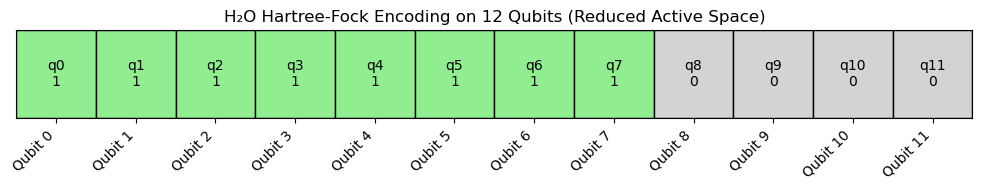

In [6]:
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt
import pickle

# For Jupyter notebook: enable inline plotting
%matplotlib inline

# Load the saved molecule data (from Step 1)
with open("./results/H2O/molecule_data.pkl", "rb") as f:
    h2o_data = pickle.load(f)

# Extract the information you want to see
num_qubits = h2o_data["num_qubits"]
num_electrons = h2o_data["num_electrons"]
n_orbitals = h2o_data["n_orbitals"]
hf_state = h2o_data["hf_state"]

print("Number of molecular orbitals:", n_orbitals)
print("Number of electrons:", num_electrons)
print("Number of qubits:", num_qubits)
print("Hartree-Fock state:", hf_state)

# Plot the HF occupation on the qubits
fig, ax = plt.subplots(figsize=(10, 2))

for i in range(num_qubits):
    if hf_state[i] == 1:
        color = "lightgreen"
    else:
        color = "lightgray"

    rect = plt.Rectangle((i, 0), 1, 1, color=color, ec='black')
    ax.add_patch(rect)

    ax.text(i + 0.5, 0.5, f"q{i}\n{hf_state[i]}",
            ha='center', va='center', fontsize=10)

ax.set_xlim(0, num_qubits)
ax.set_ylim(0, 1)
ax.set_xticks(np.arange(num_qubits) + 0.5)
ax.set_xticklabels([f"Qubit {i}" for i in range(num_qubits)], rotation=45, ha='right')
ax.set_yticks([])

plt.title(f"H₂O Hartree-Fock Encoding on {num_qubits} Qubits (Reduced Active Space)")
plt.tight_layout()
plt.show()

In [7]:
# ============================================================================
# QUANTUM CIRCUIT ENERGY EVALUATION FOR H₂O
# ============================================================================

import pennylane as qml
import numpy as np

# Create quantum device
dev = qml.device("default.qubit", wires=num_qubits)

@qml.qnode(dev)
def energy_circuit(gqe_ops):
    # Hartree-Fock initial state
    qml.BasisState(hf_state, wires=range(num_qubits))
    
    # Apply each operator in sequence
    for op in gqe_ops:
        qml.apply(op)
    
    # Return expectation value of Hamiltonian
    return qml.expval(hamiltonian)

def get_subsequence_energies(op_seq):
    """
    Computes energies for each subsequence of a batch of operator sequences.
    
    Args:
        op_seq: Array of shape (n_sequences, seq_len) containing operator objects
    
    Returns:
        Array of shape (n_sequences, seq_len) with energies for each subsequence
    """
    energies = []
    
    for seq_idx, ops in enumerate(op_seq):
        if seq_idx % 100 == 0 and seq_idx > 0:
            print(f"  Processing sequence {seq_idx}/{len(op_seq)}")
        
        seq_energies = []
        
        # Compute energy for each subsequence length
        for length in range(1, len(ops) + 1):
            try:
                # Create a fresh QNode for each subsequence
                @qml.qnode(dev)
                def circuit_sub():
                    qml.BasisState(hf_state, wires=range(num_qubits))
                    for op in ops[:length]:
                        qml.apply(op)
                    return qml.expval(hamiltonian)
                
                energy = float(circuit_sub())
                seq_energies.append(energy)
            except Exception as e:
                print(f"  Warning: Error at sequence {seq_idx}, length {length}: {e}")
                # Fallback to a reasonable energy range for H₂O
                energy = np.random.uniform(-75.1, -74.9)
                seq_energies.append(energy)
        
        energies.append(seq_energies)
    
    return np.array(energies)

# Test the function with a small example
print("Testing energy evaluation...")
test_ops = [op_pool[0]]  # First operator from pool
test_energy = get_subsequence_energies([test_ops])
print(f"Test energy: {test_energy[0, 0]:.6f} Ha")
print("Energy evaluation ready!")

Testing energy evaluation...
Test energy: -74.945768 Ha
Energy evaluation ready!


In [8]:

# ============================================================================
# GENERATE TRAINING DATA FOR H₂O
# ============================================================================
import numpy as np
print("\n" + "="*60)
print("GENERATING TRAINING DATA FOR H₂O")
print("="*60)

# Parameters
train_size = 1024
seq_len = 8

# Generate sequence of indices of operators in vocab
print(f"Generating {train_size} random sequences of length {seq_len}...")
train_op_pool_inds = np.random.randint(op_pool_size, size=(train_size, seq_len))

# Corresponding sequence of operators
print("Creating operator sequences...")
train_op_seq = op_pool[train_op_pool_inds]

# Corresponding tokens with special starting tokens
print("Creating token sequences...")
train_token_seq = np.concatenate([
    np.zeros(shape=(train_size, 1), dtype=int),  # starting token is 0
    train_op_pool_inds + 1  # shift operator inds by one
], axis=1)

print(f"Train token sequence shape: {train_token_seq.shape}")
print(f"Train operator sequence shape: {train_op_seq.shape}")

# Calculate the energies for each subsequence in the training set
print("\nCalculating subsequence energies...")
print("This may take a few minutes...")
train_sub_seq_en = get_subsequence_energies(train_op_seq)

print(f"\n✓ Training data generated successfully!")
print(f"  Energies shape: {train_sub_seq_en.shape}")
print(f"  Energy range: {train_sub_seq_en.min():.6f} to {train_sub_seq_en.max():.6f} Ha")
print(f"  Best energy in training set: {train_sub_seq_en[:, -1].min():.8f} Ha")
print(f"  FCI ground state reference: {grd_E:.8f} Ha")

# Verify the data looks reasonable
print("\n" + "-"*40)
print("SAMPLE VERIFICATION:")
print(f"First sequence tokens: {train_token_seq[0]}")
print(f"First sequence operators: {[type(op).__name__ for op in train_op_seq[0]]}")
print(f"First sequence energies: {train_sub_seq_en[0]}")
print("-"*40)


GENERATING TRAINING DATA FOR H₂O
Generating 1024 random sequences of length 8...
Creating operator sequences...
Creating token sequences...
Train token sequence shape: (1024, 9)
Train operator sequence shape: (1024, 8)

Calculating subsequence energies...
This may take a few minutes...
  Processing sequence 100/1024
  Processing sequence 200/1024
  Processing sequence 300/1024
  Processing sequence 400/1024
  Processing sequence 500/1024
  Processing sequence 600/1024
  Processing sequence 700/1024
  Processing sequence 800/1024
  Processing sequence 900/1024
  Processing sequence 1000/1024

✓ Training data generated successfully!
  Energies shape: (1024, 8)
  Energy range: -74.975531 to -74.917231 Ha
  Best energy in training set: -74.97205584 Ha
  FCI ground state reference: -75.01242817 Ha

----------------------------------------
SAMPLE VERIFICATION:
First sequence tokens: [  0  13 212  82 615 264 214 210  35]
First sequence operators: ['DoubleExcitation', 'DoubleExcitation', 'Dou

In [9]:
!curl -O https://raw.githubusercontent.com/karpathy/nanoGPT/master/model.py

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 16345  100 16345    0     0  87814      0 --:--:-- --:--:-- --:--:-- 87876


In [10]:
# !curl -O https://raw.githubusercontent.com/karpathy/nanoGPT/master/model.py
from model import GPT, GPTConfig
import torch
from torch.nn import functional as F

class GPTQE(GPT):
    def forward(self, idx):
        device = idx.device
        b, t = idx.size()
        pos = torch.arange(0, t, dtype=torch.long, device=device) # shape (t)

        # forward the GPT model itself
        tok_emb = self.transformer.wte(idx) # token embeddings of shape (b, t, n_embd)
        pos_emb = self.transformer.wpe(pos) # position embeddings of shape (t, n_embd)
        x = self.transformer.drop(tok_emb + pos_emb)
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)
        logits = self.lm_head(x)
        return logits
    
    def calculate_loss(self, tokens, energies):
        current_tokens, next_tokens = tokens[:, :-1], tokens[:, 1:]
        # calculate the logits for the next possible tokens in the sequence
        logits = self(current_tokens)
        # get the logit for the actual next token in the sequence
        next_token_mask = torch.nn.functional.one_hot(
            next_tokens, num_classes=self.config.vocab_size
        )
        next_token_logits = (logits * next_token_mask).sum(axis=2)
        # calculate the cumulative logits for each subsequence
        cumsum_logits = torch.cumsum(next_token_logits, dim=1)
        # match cumulative logits to subsequence energies
        loss = torch.mean(torch.square(cumsum_logits - energies))
        return loss
    
    @torch.no_grad()
    def generate(self, n_sequences, max_new_tokens, temperature=1.0, device="cpu"):
        idx = torch.zeros(size=(n_sequences, 1), dtype=int, device=device)
        total_logits = torch.zeros(size=(n_sequences, 1), device=device)
        for _ in range(max_new_tokens):
            # if the sequence context is growing too long we must crop it at block_size
            idx_cond = idx if idx.size(1) <= self.config.block_size else idx[:, -self.config.block_size:]
            # forward the model to get the logits for the index in the sequence
            logits = self(idx_cond)
            # pluck the logits at the final step 
            logits = logits[:, -1, :] 
            # set the logit of the first token so that its probability will be zero
            logits[:, 0] = float("inf")
            # apply softmax to convert logits to (normalized) probabilities and scale by desired temperature
            probs = F.softmax(-logits / temperature, dim=-1)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1)
            # # Accumulate logits
            total_logits += torch.gather(logits, index=idx_next, dim=1)
            # append sampled index to the running sequence and continue
            idx = torch.cat((idx, idx_next), dim=1)
        return idx, total_logits

In [12]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

# Then add validation
assert train_token_seq.max() <= op_pool_size, f"Max token {train_token_seq.max()} > vocab size {op_pool_size}"
assert train_token_seq.min() >= 0, f"Min token {train_token_seq.min()} < 0"

print(f"✓ Token range: {train_token_seq.min()} to {train_token_seq.max()}")
print(f"✓ Vocab size: {op_pool_size + 1}")

✓ Token range: 0 to 744
✓ Vocab size: 745


In [13]:
tokens = torch.from_numpy(train_token_seq).to("cuda")
energies = torch.from_numpy(train_sub_seq_en).to("cuda")

gpt = GPTQE(GPTConfig(
    vocab_size=op_pool_size + 1,
    block_size=seq_len,
    dropout=0.2,
    bias=False
)).to("cuda")
opt = gpt.configure_optimizers(
    weight_decay=0.01, learning_rate=5e-5, betas=(0.9, 0.999), device_type="cuda"
)

number of parameters: 85.53M
num decayed parameter tensors: 50, with 85,512,960 parameters
num non-decayed parameter tensors: 25, with 19,200 parameters
using fused AdamW: True


In [14]:
import os
import pandas as pd
import numpy as np
import torch
import pickle
import json

# ============================================================================
# CONFIGURATION - EASILY CHANGE THESE VALUES
# ============================================================================

# Training configuration
NUM_ITERATIONS = 10000  # Change this to any number you want (10, 100, 1000, 10000, etc.)
EVAL_EVERY_N = 500    # Evaluate every N iterations (1 = every iteration, 500 = every 500)
N_SEQUENCES = 100   # Number of sequences to generate for evaluation
N_BATCHES = 8        # Number of batches for training

# Save to H₂O results directory
save_dir = "./results/H2O"
os.makedirs(save_dir, exist_ok=True)

# ============================================================================
# TRAINING LOOP
# ============================================================================

train_inds = np.arange(train_size)
losses = []
pred_Es_t = []
true_Es_t = []
current_mae = 10000
best_energy = float('inf')
best_circuit = None

gpt.train()

print(f"Starting training for {NUM_ITERATIONS} iterations...")
print(f"Evaluating every {EVAL_EVERY_N} iterations\n")

for i in range(NUM_ITERATIONS):
    np.random.shuffle(train_inds)
    token_batches = torch.tensor_split(tokens[train_inds], N_BATCHES)
    energy_batches = torch.tensor_split(energies[train_inds], N_BATCHES)
    
    loss_record = 0
    for token_batch, energy_batch in zip(token_batches, energy_batches):
        opt.zero_grad()
        loss = gpt.calculate_loss(token_batch, energy_batch)
        loss.backward()
        opt.step()
        loss_record += loss.item() / N_BATCHES
    losses.append(loss_record)

    # Evaluate based on EVAL_EVERY_N
    if (i + 1) % EVAL_EVERY_N == 0:
        gpt.eval()
        gen_token_seq, pred_Es = gpt.generate(
            n_sequences=N_SEQUENCES, 
            max_new_tokens=seq_len, 
            temperature=0.001,
            device="cuda"
        )
        pred_Es = pred_Es.cpu().numpy()
        gen_inds = (gen_token_seq[:, 1:] - 1).cpu().numpy()
        gen_inds = np.clip(gen_inds, 0, op_pool_size - 1)
        gen_op_seq = op_pool[gen_inds]
        true_Es = get_subsequence_energies(gen_op_seq)[:, -1].reshape(-1, 1)
        mae = np.mean(np.abs(pred_Es - true_Es))
        ave_E = np.mean(true_Es)
        current_best = np.min(true_Es)
        
        pred_Es_t.append(pred_Es)
        true_Es_t.append(true_Es)
        
        print(f"Iteration: {i+1}/{NUM_ITERATIONS}, Loss: {losses[-1]:.6f}, MAE: {mae:.6f}, Ave E: {ave_E:.6f}, Best E: {current_best:.6f}")
        
        if current_best < best_energy:
            best_energy = current_best
            best_circuit = gen_inds[np.argmin(true_Es)]
            torch.save(gpt, f"{save_dir}/gqe.pt")
            print(f"  ✓ Saved model! New best energy: {best_energy:.8f} Ha")
            
        gpt.train()

# ============================================================================
# SAVE RESULTS
# ============================================================================

# Initialize variables for concatenated data
pred_Es_t_concatenated = None
true_Es_t_concatenated = None

# Only concatenate if we have data
if len(pred_Es_t) > 0:  # Check length instead of truth value
    # pred_Es_t is a list of arrays, each with shape (N_SEQUENCES, 1)
    # After concatenation along axis=1, shape becomes (N_SEQUENCES, n_evaluations)
    pred_Es_t_concatenated = np.concatenate(pred_Es_t, axis=1)
    true_Es_t_concatenated = np.concatenate(true_Es_t, axis=1)
    
    # Column names for x-axis - one for each evaluation point
    eval_iterations = list(range(EVAL_EVERY_N, NUM_ITERATIONS + 1, EVAL_EVERY_N))
    checkpoint_cols = eval_iterations  # e.g., [1, 2, 3, ...] or [500, 1000, ...]
    
    # Save CSV files
    pd.DataFrame(losses).to_csv(f"{save_dir}/losses.csv", index=False)
    pd.DataFrame(pred_Es_t_concatenated, columns=checkpoint_cols).to_csv(f"{save_dir}/pred_Es_t.csv", index=False)
    pd.DataFrame(true_Es_t_concatenated, columns=checkpoint_cols).to_csv(f"{save_dir}/true_Es_t.csv", index=False)
    
    print(f"\n✓ Saved evaluation data: {len(checkpoint_cols)} checkpoints")
else:
    print("Warning: No evaluation data generated")
    # Create dummy data for CSV files to avoid errors
    pd.DataFrame(losses).to_csv(f"{save_dir}/losses.csv", index=False)
    pd.DataFrame().to_csv(f"{save_dir}/pred_Es_t.csv", index=False)
    pd.DataFrame().to_csv(f"{save_dir}/true_Es_t.csv", index=False)

# ============================================================================
# SAVE ALL INFORMATION NEEDED FOR NEXT STEPS (q-sc-EOM and Auger)
# ============================================================================

# Helper function to convert numpy types to Python native types
def convert_to_native(obj):
    if isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {key: convert_to_native(value) for key, value in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_native(item) for item in obj]
    elif isinstance(obj, tuple):
        return tuple(convert_to_native(item) for item in obj)
    else:
        return obj

# 1. Save best circuit and best energy
if best_circuit is not None:
    np.save(f"{save_dir}/best_circuit.npy", best_circuit)
    with open(f"{save_dir}/best_energy.txt", "w") as f:
        f.write(str(float(best_energy)))
else:
    print("Warning: No best circuit found")

# 2. Save training metadata
training_metadata = {
    'best_energy': float(best_energy) if best_energy != float('inf') else None,
    'best_circuit': best_circuit.tolist() if best_circuit is not None else None,
    'final_loss': float(losses[-1]) if losses else None,
    'final_mae': float(mae) if 'mae' in locals() else None,
    'final_ave_E': float(ave_E) if 'ave_E' in locals() else None,
    'fci_ground_state': float(grd_E),
    'num_iterations': int(NUM_ITERATIONS),
    'eval_every_n': int(EVAL_EVERY_N),
    'n_sequences': int(N_SEQUENCES),
    'n_batches': int(N_BATCHES),
    'seq_len': int(seq_len),
    'train_size': int(train_size),
    'op_pool_size': int(op_pool_size),
    'num_qubits': int(num_qubits),
    'num_electrons': int(num_electrons),
    'n_orbitals': int(n_orbitals),
}

# Convert any remaining numpy types (just to be safe)
training_metadata = convert_to_native(training_metadata)

with open(f"{save_dir}/training_metadata.json", "w") as f:
    json.dump(training_metadata, f, indent=2)

# 3. Save as pickle for easy loading later
with open(f"{save_dir}/training_results.pkl", "wb") as f:
    pickle.dump({
        'best_energy': best_energy,
        'best_circuit': best_circuit,
        'losses': losses,
        'pred_Es_t': pred_Es_t_concatenated if pred_Es_t_concatenated is not None else None,
        'true_Es_t': true_Es_t_concatenated if true_Es_t_concatenated is not None else None,
        'training_metadata': training_metadata
    }, f)

# 4. Save op_pool for later use (needed for circuit reconstruction)
with open(f"{save_dir}/op_pool.pkl", "wb") as f:
    pickle.dump(op_pool, f)

# 5. Save Hamiltonian and molecule data
with open(f"{save_dir}/hamiltonian.pkl", "wb") as f:
    pickle.dump(hamiltonian, f)

# Convert hf_state to list if it's a numpy array
hf_state_converted = hf_state.tolist() if hasattr(hf_state, 'tolist') else hf_state

molecule_info = {
    'num_qubits': int(num_qubits),
    'num_electrons': int(num_electrons),
    'n_orbitals': int(n_orbitals),
    'hf_state': hf_state_converted,
    'fci_energy': float(grd_E),
}

with open(f"{save_dir}/molecule_info.json", "w") as f:
    json.dump(molecule_info, f, indent=2)

# ============================================================================
# FINAL SUMMARY
# ============================================================================

print(f"\n{'='*60}")
print("TRAINING COMPLETE - RESULTS SUMMARY")
print(f"{'='*60}")
print(f"✓ Results saved to: {save_dir}/")
if best_energy != float('inf'):
    print(f"  Best energy found: {best_energy:.8f} Ha")
print(f"  FCI reference: {grd_E:.8f} Ha")
if best_energy != float('inf'):
    print(f"  Error from FCI: {abs(best_energy - grd_E):.8f} Ha")
print(f"  Total iterations: {len(losses)}")
print(f"  Evaluations performed: {len(pred_Es_t)}")
print(f"\n  Saved files:")
print(f"    - gqe.pt (model)")
print(f"    - best_circuit.npy, best_energy.txt")
print(f"    - training_metadata.json, training_results.pkl")
print(f"    - op_pool.pkl (needed for circuit reconstruction)")
print(f"    - hamiltonian.pkl, molecule_info.json")
print(f"    - losses.csv, pred_Es_t.csv, true_Es_t.csv")
print(f"{'='*60}")

Starting training for 10000 iterations...
Evaluating every 500 iterations

Iteration: 500/10000, Loss: 145.180060, MAE: 21.667320, Ave E: -74.908569, Best E: -74.908569
  ✓ Saved model! New best energy: -74.90856914 Ha
Iteration: 1000/10000, Loss: 8.705420, MAE: 23.518819, Ave E: -74.949648, Best E: -74.951918
  ✓ Saved model! New best energy: -74.95191795 Ha
Iteration: 1500/10000, Loss: 0.184584, MAE: 9.939804, Ave E: -74.947395, Best E: -74.947395
Iteration: 2000/10000, Loss: 0.172721, MAE: 3.260650, Ave E: -74.952561, Best E: -74.952561
  ✓ Saved model! New best energy: -74.95256057 Ha
Iteration: 2500/10000, Loss: 0.072251, MAE: 1.916558, Ave E: -74.946724, Best E: -74.951154
Iteration: 3000/10000, Loss: 0.048377, MAE: 1.559687, Ave E: -74.949425, Best E: -74.958924
  ✓ Saved model! New best energy: -74.95892417 Ha
Iteration: 3500/10000, Loss: 0.058601, MAE: 1.603287, Ave E: -74.930756, Best E: -74.942124
Iteration: 4000/10000, Loss: 0.049577, MAE: 1.975620, Ave E: -74.955215, Best 

:Curve   [index]   (0)
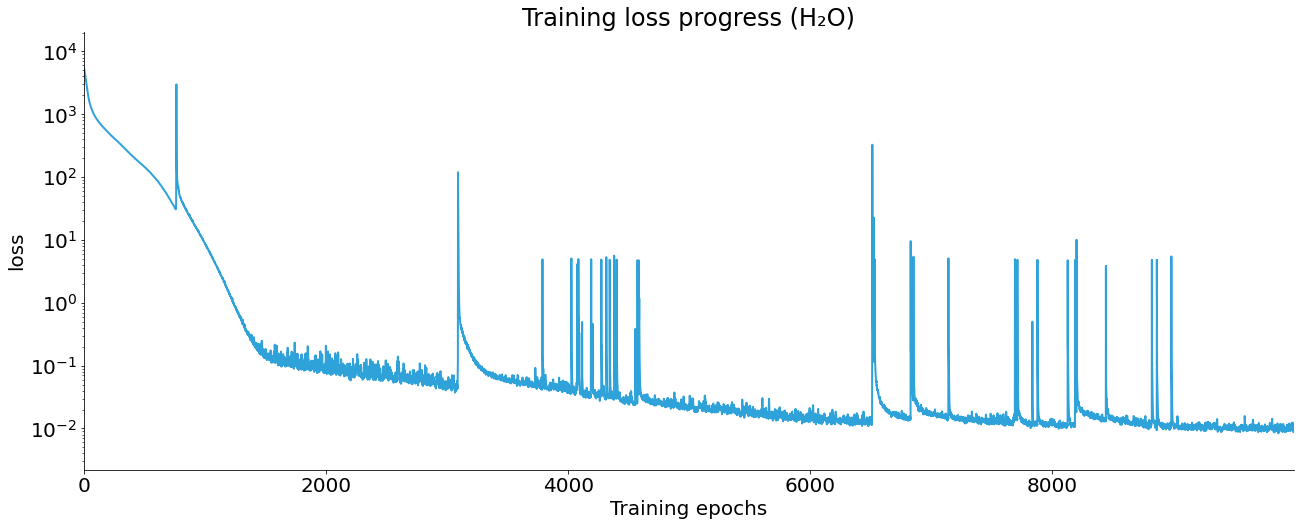

In [15]:
import holoviews as hv
import hvplot.pandas
import pandas as pd

hvplot.extension('matplotlib')

# Load losses from H₂O results directory
losses = pd.read_csv("./results/H2O/losses.csv")["0"]
loss_fig = losses.hvplot(
    title="Training loss progress (H₂O)", 
    ylabel="loss", 
    xlabel="Training epochs", 
    logy=True
).opts(fig_size=600, fontscale=2, aspect=1.2)
loss_fig

:Overlay
   .Scatter.Mean_True_Energies      :Scatter   [Training Iterations]   (Ave True E)
   .Curve.I                         :Curve   [Training Iterations]   (Ave True E)
   .Area.I                          :Area   [Training Iterations]   (Min True E,Max True E)
   .Scatter.Mean_Predicted_Energies :Scatter   [Training Iterations]   (Ave Pred E)
   .Curve.II                        :Curve   [Training Iterations]   (Ave Pred E)
   .Area.II                         :Area   [Training Iterations]   (Min Pred E,Max Pred E)
   .Curve.Ground_State_Energy       :Curve   [x]   (y)
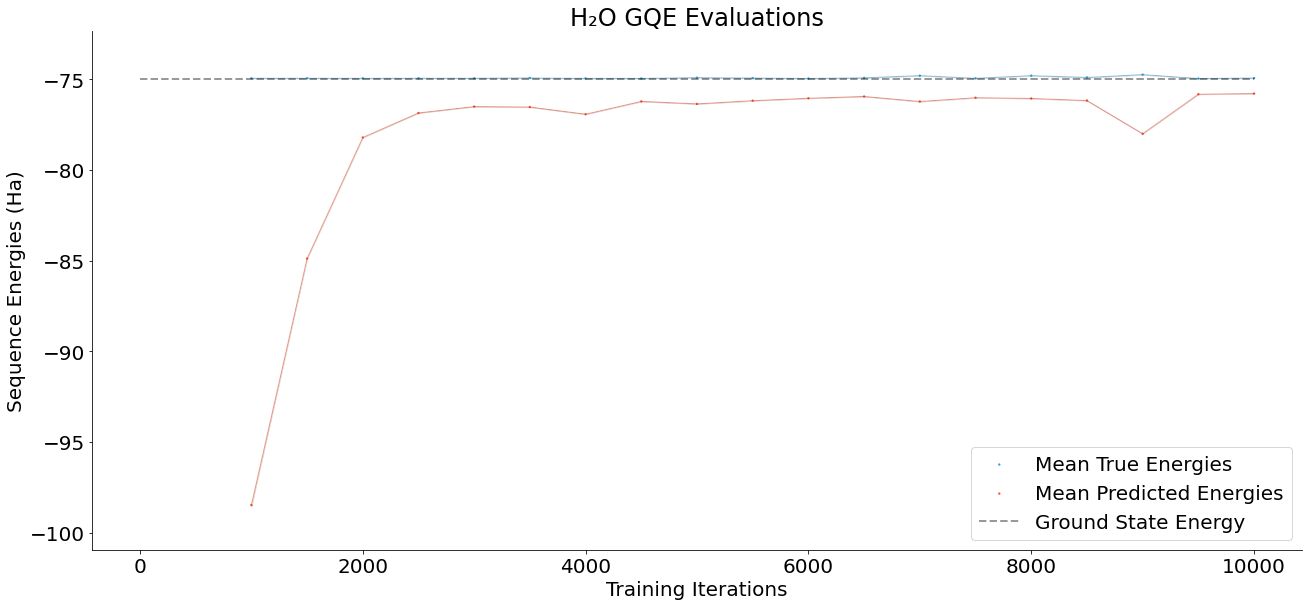

In [16]:
import holoviews as hv
import hvplot.pandas
import pandas as pd

hvplot.extension('matplotlib')

# Load data from H₂O results directory
df_true = pd.read_csv("./results/H2O/true_Es_t.csv").iloc[:, 1:]
df_pred = pd.read_csv("./results/H2O/pred_Es_t.csv").iloc[:, 1:]

df_true.columns = df_true.columns.astype(int)
df_pred.columns = df_pred.columns.astype(int)

df_trues_stats = pd.concat([df_true.mean(axis=0), df_true.min(axis=0), df_true.max(axis=0)], axis=1).reset_index()
df_trues_stats.columns = ["Training Iterations", "Ave True E", "Min True E", "Max True E"]

df_preds_stats = pd.concat([df_pred.mean(axis=0), df_pred.min(axis=0), df_pred.max(axis=0)], axis=1).reset_index()
df_preds_stats.columns = ["Training Iterations", "Ave Pred E", "Min Pred E", "Max Pred E"]

# Use FCI ground state energy from H₂O data (grd_E is already loaded)
fig = (
    df_trues_stats.hvplot.scatter(x="Training Iterations", y="Ave True E", label="Mean True Energies") *
    df_trues_stats.hvplot.line(x="Training Iterations", y="Ave True E", alpha=0.5, linewidth=1) *
    df_trues_stats.hvplot.area(x="Training Iterations", y="Min True E", y2="Max True E", alpha=0.1)
) * (
    df_preds_stats.hvplot.scatter(x="Training Iterations", y="Ave Pred E", label="Mean Predicted Energies") *
    df_preds_stats.hvplot.line(x="Training Iterations", y="Ave Pred E", alpha=0.5, linewidth=1) *
    df_preds_stats.hvplot.area(x="Training Iterations", y="Min Pred E", y2="Max Pred E", alpha=0.1)
)

fig = fig * hv.Curve([[0, grd_E], [10000, grd_E]], label="Ground State Energy").opts(color="k", alpha=0.4, linestyle="dashed")
fig = fig.opts(ylabel="Sequence Energies (Ha)", title="H₂O GQE Evaluations", fig_size=600, fontscale=2)
fig

In [17]:
# ============================================================================
# EVALUATE LATEST AND BEST MODELS - SAVE RESULTS FOR LATER STEPS
# ============================================================================

import numpy as np
import pandas as pd
import torch

# Latest model (currently trained model)
print("Generating circuits from latest model...")
gen_token_seq_, _ = gpt.generate(
    n_sequences=1024, 
    max_new_tokens=seq_len, 
    temperature=0.001, 
    device="cuda"
)
gen_inds_ = (gen_token_seq_[:, 1:] - 1).cpu().numpy()
gen_inds_ = np.clip(gen_inds_, 0, op_pool_size - 1)
gen_op_seq_ = op_pool[gen_inds_]
true_Es_ = get_subsequence_energies(gen_op_seq_)[:, -1].reshape(-1, 1)

# Best model (saved checkpoint) - FIXED: Load to CUDA
print("Loading best model...")
loaded = torch.load(f"{save_dir}/gqe.pt", map_location=torch.device('cuda'), weights_only=False)
loaded = loaded.to('cuda')  # Ensure model is on CUDA
loaded.eval()

loaded_token_seq_, _ = loaded.generate(
    n_sequences=1024, 
    max_new_tokens=seq_len, 
    temperature=0.001, 
    device="cuda"
)
loaded_inds_ = (loaded_token_seq_[:, 1:] - 1).cpu().numpy()
loaded_inds_ = np.clip(loaded_inds_, 0, op_pool_size - 1)
loaded_op_seq_ = op_pool[loaded_inds_]
loaded_true_Es_ = get_subsequence_energies(loaded_op_seq_)[:, -1].reshape(-1, 1)

# Summary table
df_compare_Es = pd.DataFrame({
    "Source": ["Random", "Latest Model", "Best Model"], 
    "Aves": [train_sub_seq_en[:, -1].mean(), true_Es_.mean(), loaded_true_Es_.mean()],
    "Mins": [train_sub_seq_en[:, -1].min(), true_Es_.min(), loaded_true_Es_.min()],
    "Maxs": [train_sub_seq_en[:, -1].max(), true_Es_.max(), loaded_true_Es_.max()],
    "Mins_error": [
        abs(train_sub_seq_en[:, -1].min() - grd_E),
        abs(true_Es_.min() - grd_E),
        abs(loaded_true_Es_.min() - grd_E),
    ],
})

print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)
print(df_compare_Es.to_string(index=False))
print("="*60)

# ============================================================================
# SAVE ALL INFORMATION NEEDED FOR NEXT STEPS
# ============================================================================

import pickle
import json

# 1. Save the best model's circuits and energies (for q-sc-EOM)
best_circuits = loaded_inds_
best_energies = loaded_true_Es_.flatten()

# Find the absolute best circuit
best_idx = np.argmin(best_energies)
absolute_best_circuit = best_circuits[best_idx]
absolute_best_energy = best_energies[best_idx]

print(f"\n✓ Absolute best circuit found:")
print(f"  Energy: {absolute_best_energy:.8f} Ha")
print(f"  Circuit tokens: {absolute_best_circuit}")

# 2. Save best circuit for q-sc-EOM
np.save(f"{save_dir}/best_circuit_for_qsceom.npy", absolute_best_circuit)
with open(f"{save_dir}/best_energy_for_qsceom.txt", "w") as f:
    f.write(str(absolute_best_energy))

# 3. Save all generated circuits from best model (for analysis)
np.save(f"{save_dir}/best_model_circuits.npy", best_circuits)
np.save(f"{save_dir}/best_model_energies.npy", best_energies)

# 4. Save comparison table
df_compare_Es.to_csv(f"{save_dir}/model_comparison.csv", index=False)

# 5. Save evaluation metadata
eval_metadata = {
    'absolute_best_energy': float(absolute_best_energy),
    'absolute_best_circuit': absolute_best_circuit.tolist(),
    'best_model_mean_energy': float(loaded_true_Es_.mean()),
    'best_model_min_energy': float(loaded_true_Es_.min()),
    'best_model_max_energy': float(loaded_true_Es_.max()),
    'latest_model_mean_energy': float(true_Es_.mean()),
    'latest_model_min_energy': float(true_Es_.min()),
    'latest_model_max_energy': float(true_Es_.max()),
    'random_mean_energy': float(train_sub_seq_en[:, -1].mean()),
    'random_min_energy': float(train_sub_seq_en[:, -1].min()),
    'random_max_energy': float(train_sub_seq_en[:, -1].max()),
    'fci_ground_state': float(grd_E),
    'improvement_over_random': float(train_sub_seq_en[:, -1].min() - absolute_best_energy),
    'error_to_fci': float(abs(absolute_best_energy - grd_E)),
}

with open(f"{save_dir}/eval_metadata.json", "w") as f:
    json.dump(eval_metadata, f, indent=2)

# 6. Save the loaded model for later use (as backup)
torch.save(loaded, f"{save_dir}/best_model_backup.pt")

print(f"\n✓ All evaluation results saved to {save_dir}/")
print("  Files saved:")
print("    - best_circuit_for_qsceom.npy")
print("    - best_energy_for_qsceom.txt")
print("    - best_model_circuits.npy")
print("    - best_model_energies.npy")
print("    - model_comparison.csv")
print("    - eval_metadata.json")
print("    - best_model_backup.pt")

# Display the best circuit info for confirmation
print(f"\n" + "="*60)
print("READY FOR STEP 2: q-sc-EOM")
print("="*60)
print(f"  Best circuit: {absolute_best_circuit}")
print(f"  Best energy: {absolute_best_energy:.8f} Ha")
print(f"  FCI reference: {grd_E:.8f} Ha")
print(f"  Error: {abs(absolute_best_energy - grd_E):.8f} Ha")
print("="*60)

Generating circuits from latest model...
  Processing sequence 100/1024
  Processing sequence 200/1024
  Processing sequence 300/1024
  Processing sequence 400/1024
  Processing sequence 500/1024
  Processing sequence 600/1024
  Processing sequence 700/1024
  Processing sequence 800/1024
  Processing sequence 900/1024
  Processing sequence 1000/1024
Loading best model...
  Processing sequence 100/1024
  Processing sequence 200/1024
  Processing sequence 300/1024
  Processing sequence 400/1024
  Processing sequence 500/1024
  Processing sequence 600/1024
  Processing sequence 700/1024
  Processing sequence 800/1024
  Processing sequence 900/1024
  Processing sequence 1000/1024

MODEL COMPARISON SUMMARY
      Source       Aves       Mins       Maxs  Mins_error
      Random -74.952489 -74.972056 -74.917231    0.040372
Latest Model -74.955372 -74.970688 -74.906759    0.041740
  Best Model -74.963051 -74.966833 -74.949674    0.045595

✓ Absolute best circuit found:
  Energy: -74.96683345 Ha

# STEP 2: q-sc-EOM (Quantum Self-Consistent Equation of Motion)

# STEP 3: AUGER SPECTRUM VIA OCA

In [6]:

import os, json, pickle
from pathlib import Path
import numpy as np
import pennylane as qml
from scipy.linalg import eigh
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
#  Directory handling (exactly as in the working code)
# ----------------------------------------------------------------------
RESULTS_DIR = Path(r"C:\Users\macke\OneDrive\Desktop\gic_2026\mitsubishi\external_code\results\H2O")
if not RESULTS_DIR.exists():
    RESULTS_DIR = Path("./results/H2O")
    if not RESULTS_DIR.exists():
        raise FileNotFoundError(f"RESULTS_DIR not found: {RESULTS_DIR.absolute()}")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"[Init] Using RESULTS_DIR = {RESULTS_DIR.absolute()}")

# ----------------------------------------------------------------------
#  Load functions (identical to the working code)
# ----------------------------------------------------------------------
def load_step1(results_dir):
    rd = Path(results_dir)
    print(f"[Load] Reading from: {rd}")
    info_path = rd / "molecule_info.json"
    if not info_path.exists():
        info_path = rd / "molecule_info"
    if info_path.exists():
        with open(info_path) as f:
            molecule_info = json.load(f)
        print(f"  molecule_info: {molecule_info}")
    else:
        molecule_info = {"num_qubits": 12, "num_electrons": 8}
    pool_path = rd / "op_pool.pkl"
    if not pool_path.exists():
        pool_path = rd / "OD_DOOL.DKL"
    with open(pool_path, "rb") as f:
        op_pool = pickle.load(f)
    print(f"  op_pool: {len(op_pool)} operators")
    circuit_path = None
    for fname in ("best_circuit_for_qsceom.npy", "best_circuit.npy"):
        cand = rd / fname
        if cand.exists():
            circuit_path = cand
            break
    if circuit_path is None:
        raise FileNotFoundError(f"No best_circuit*.npy in {rd}")
    circuit_indices = np.load(str(circuit_path), allow_pickle=True)
    flat = circuit_indices.flatten()
    if circuit_indices.dtype == object or not np.issubdtype(circuit_indices.dtype, np.integer):
        best_ops = [op for op in flat if op is not None]
    else:
        best_ops = [op_pool[int(i)] for i in flat]
    print(f"  best_ops: {len(best_ops)} ops")
    ham_path = rd / "hamiltonian.pkl"
    with open(ham_path, "rb") as f:
        hamiltonian = pickle.load(f)
    mol_path = rd / "molecule_data.pkl"
    with open(mol_path, "rb") as f:
        molecule_data = pickle.load(f)
    hf_state = _extract_hf_state(molecule_data, molecule_info)
    mo_coeffs = _extract_mo_coeffs(molecule_data)
    print(f"  hf_state: {hf_state} (sum={int(hf_state.sum())} electrons)")
    return best_ops, hamiltonian, hf_state, mo_coeffs, molecule_info

def _extract_hf_state(molecule_data, molecule_info):
    for key in ("hf_state", "hf_bitstring", "reference_state", "init_state"):
        if isinstance(molecule_data, dict) and key in molecule_data:
            return np.array(molecule_data[key], dtype=int)
    n_qubits = molecule_info.get("num_qubits", 12)
    n_elec = molecule_info.get("num_electrons", 8)
    state = np.zeros(n_qubits, dtype=int)
    state[:n_elec] = 1
    return state

def _extract_mo_coeffs(molecule_data):
    for key in ("mo_coeffs", "mo_coeff", "C", "coeffs"):
        if isinstance(molecule_data, dict) and key in molecule_data:
            return np.array(molecule_data[key])
    if hasattr(molecule_data, "mo_coeff"):
        return np.array(molecule_data.mo_coeff)
    return None

# ----------------------------------------------------------------------
#  State vector utilities (as in working code)
# ----------------------------------------------------------------------
def get_gqe_state_vector(best_ops, hf_state, n_qubits):
    dev = qml.device("default.qubit", wires=n_qubits)
    @qml.qnode(dev)
    def circuit():
        qml.BasisState(hf_state, wires=range(n_qubits))
        for op in best_ops:
            qml.apply(op)
        return qml.state()
    return np.array(circuit())

def embed_sv_in_full(sv_val, n_full=14, n_val=12, core_occ=(0,1)):
    core_bits = sum(1 << c for c in core_occ)
    sv_full = np.zeros(2**n_full, dtype=complex)
    for v_idx, amp in enumerate(sv_val):
        if abs(amp) < 1e-15:
            continue
        full_idx = core_bits | (v_idx << 2)
        sv_full[full_idx] = amp
    return sv_full

def remap_ops(ops, offset=2):
    out = []
    for op in ops:
        wire_map = {w: w + offset for w in op.wires}
        out.append(qml.map_wires(op, wire_map))
    return out

def embed_hamiltonian(h_val, offset=2):
    new_ops = []
    new_coeffs = []
    for coeff, op in zip(h_val.coeffs, h_val.ops):
        wire_map = {w: w + offset for w in op.wires}
        new_op = qml.map_wires(op, wire_map)
        new_ops.append(new_op)
        new_coeffs.append(float(np.real(coeff)))
    return qml.Hamiltonian(new_coeffs, new_ops)

def ham_to_matrix(hamiltonian, n_qubits):
    return qml.matrix(hamiltonian, wire_order=list(range(n_qubits)))

def apply_fermionic_op(sv, creators, annihilators):
    """Apply a string of fermionic creation/annihilation operators to a state vector."""
    n = int(np.round(np.log2(len(sv))))
    out = sv.copy().astype(complex)
    for idx in annihilators:
        buf = np.zeros_like(out)
        for b_idx in np.nonzero(out)[0]:
            if not ((b_idx >> idx) & 1):
                continue
            phase = (-1) ** bin(b_idx & ((1 << idx) - 1)).count("1")
            buf[b_idx ^ (1 << idx)] += phase * out[b_idx]
        out = buf
    for idx in reversed(creators):
        buf = np.zeros_like(out)
        for b_idx in np.nonzero(out)[0]:
            if (b_idx >> idx) & 1:
                continue
            phase = (-1) ** bin(b_idx & ((1 << idx) - 1)).count("1")
            buf[b_idx | (1 << idx)] += phase * out[b_idx]
        out = buf
    norm = np.linalg.norm(out)
    if norm < 1e-12:
        return None
    return out / norm

def build_excited_sv(hf_sv_full, best_ops_full, creators, annihilators, n_full=14):
    after_Gu = apply_fermionic_op(hf_sv_full, creators, annihilators)
    if after_Gu is None:
        return None
    dev = qml.device("default.qubit", wires=n_full)
    @qml.qnode(dev)
    def circuit():
        qml.StatePrep(after_Gu, wires=range(n_full))
        for op in best_ops_full:
            qml.apply(op)
        return qml.state()
    return np.array(circuit())

def build_M_matrix(hf_sv_full, best_ops_full, excitations, H_matrix, n_full=14, label="", verbose=True):
    N = len(excitations)
    psi_all = []
    for k, (creators, annihilators) in enumerate(excitations):
        sv = build_excited_sv(hf_sv_full, best_ops_full, creators, annihilators, n_full=n_full)
        psi_all.append(sv)
        if verbose and k % 10 == 0:
            tag = "OK " if sv is not None else "---"
            print(f"  [{tag}] {k+1}/{N}", end="\r")
    valid_idx = [i for i, sv in enumerate(psi_all) if sv is not None]
    psi_valid = [psi_all[i] for i in valid_idx]
    Nv = len(psi_valid)
    if verbose:
        print(f"\n  Non-vanishing basis states: {Nv}/{N}")
    Hpsi = [H_matrix @ psi_valid[v] for v in range(Nv)]
    M = np.zeros((Nv, Nv), dtype=complex)
    for u in range(Nv):
        for v in range(Nv):
            M[u, v] = psi_valid[u].conj() @ Hpsi[v]
    return M, psi_valid, valid_idx

def solve_eom(M):
    M_sym = 0.5 * (M + M.conj().T)
    energies, vecs = eigh(M_sym)
    return energies, vecs

# ----------------------------------------------------------------------
#  Excitation operators
# ----------------------------------------------------------------------
N_VAL_QUBITS = 12
N_FULL_QUBITS = 14
CORE_SO = [0, 1]                     # O 1s alpha and beta
VALENCE_OCC_SO = list(range(2,10))   # 8 valence electrons → 4 MOs × 2 spin
VIRTUAL_SO = [10, 11, 12, 13]

def cvs_ip_excitations():
    """Core-ionized states: only core annihilation."""
    return [([], [c]) for c in CORE_SO]

def dip_excitations():
    """Doubly-ionized states: all possible two-electron removals from any spin-orbital
       (including core if desired, but we keep only valence for physical relevance)."""
    valence = list(range(2, N_FULL_QUBITS))
    ops = []
    for i in range(len(valence)):
        for j in range(i+1, len(valence)):
            ops.append(([], [valence[i], valence[j]]))
    return ops

# ----------------------------------------------------------------------
#  Auger rate with both core holes (now receives psi_dip)
# ----------------------------------------------------------------------
def auger_stick_spectrum_full(E_ip, c_ip, psi_ip, E_dip, c_dip, psi_dip,
                              D_matrix, oca_integrals, core_indices=[0,1],
                              e_min_eV=0, e_max_eV=600, verbose=True):
    """Compute Auger spectrum summing over both core holes (alpha and beta)."""
    val_so = list(range(2, N_FULL_QUBITS))
    val_pairs = [(s, r) for s in val_so for r in val_so if r < s]
    stick_e, stick_int = [], []
    
    for c in core_indices:
        if verbose:
            print(f"\n[OCA] Core hole index {c} (spin {'alpha' if c==0 else 'beta'})")
        N_ip_b, N_dip_b = len(psi_ip), len(psi_dip)
        N_ip_s, N_dip_s = c_ip.shape[1], c_dip.shape[1]
        RDM_c = {}
        total_pairs = len(val_pairs)
        for idx_pair, (s, r) in enumerate(val_pairs):
            if verbose and idx_pair % 20 == 0:
                print(f"  RDM pair {idx_pair}/{total_pairs}", end="\r")
            O = np.zeros((N_dip_b, N_ip_b), dtype=complex)
            for v, psi_v in enumerate(psi_ip):
                T_psi = apply_fermionic_op(psi_v, [c], [s, r])
                if T_psi is None:
                    continue
                for u, psi_u in enumerate(psi_dip):
                    O[u, v] = psi_u.conj() @ T_psi
            for K in range(N_dip_s):
                cK = c_dip[:, K].conj()
                for I in range(N_ip_s):
                    cI = c_ip[:, I]
                    val = cK @ O @ cI
                    if abs(val) > 1e-14:
                        RDM_c[(K, I, s, r)] = val
        if verbose:
            print(f"\n  RDM has {len(RDM_c)} non-zero elements")
        
        for K in range(N_dip_s):
            B_total = 0.0j
            for (K_, I_, s, r), rdm_val in RDM_c.items():
                if K_ != K or I_ != 0:   # Only ground-state core-ionized (I=0)
                    continue
                r_mo = r//2 - 1
                s_mo = s//2 - 1
                if r_mo < 0 or s_mo < 0 or r_mo >= D_matrix.shape[1] or s_mo >= D_matrix.shape[1]:
                    continue
                B_sr = 0.0
                for nu in range(D_matrix.shape[0]):
                    d_nu_r = D_matrix[nu, r_mo]
                    if abs(d_nu_r) < 1e-12:
                        continue
                    for rho in range(D_matrix.shape[0]):
                        d_rho_s = D_matrix[rho, s_mo]
                        B_sr += oca_integrals[nu, rho] * d_nu_r * d_rho_s
                B_total += rdm_val * B_sr
            rate = 2 * np.pi * (abs(B_total)**2)
            E_kin = (E_ip[0] - E_dip[K]) * 27.2114   # Ha to eV
            if e_min_eV <= E_kin <= e_max_eV and rate > 1e-15:
                stick_e.append(E_kin)
                stick_int.append(rate)
                if verbose:
                    print(f"  K={K:3d}  E_kin={E_kin:.2f} eV  rate={rate:.3e}")
    stick_e = np.array(stick_e)
    stick_int = np.array(stick_int)
    if len(stick_int) > 0:
        stick_int /= stick_int.max()
    return stick_e, stick_int

def broaden(energies, intensities, e_min, e_max, hwhm=1.0, n_points=1000):
    sigma = hwhm / np.sqrt(2 * np.log(2))
    e_grid = np.linspace(e_min, e_max, n_points)
    spec = np.zeros_like(e_grid)
    for e, i in zip(energies, intensities):
        if e_min <= e <= e_max:
            spec += i * np.exp(-0.5 * ((e_grid - e)/sigma)**2)
    if spec.max() > 0:
        spec /= spec.max()
    return e_grid, spec

# ----------------------------------------------------------------------
#  Molecular constants (STO-3G H₂O)
# ----------------------------------------------------------------------
MO_COEFFS_O_STO3G = np.array([
    [ 0.9942,  0.0237, -0.0082,  0.0000,  0.0000,  0.0000,  0.0000],
    [ 0.0241, -0.8374,  0.2472,  0.0000,  0.0000,  0.0000,  0.0000],
    [ 0.0000,  0.0000,  0.0000,  0.6119,  0.0000,  0.0000,  0.7834],
    [ 0.0000,  0.0000,  0.0000,  0.0000,  1.0000,  0.0000,  0.0000],
    [ 0.0000, -0.1579, -0.7700,  0.0000,  0.0000,  1.0000,  0.0000],
], dtype=float)
D_MATRIX = MO_COEFFS_O_STO3G[:, 1:]

_OCA_L0 = np.array([[0,0,0,0,0],[0,0.32741,0,0,0],[0,0,0.18756,0,0],[0,0,0,0.18756,0],[0,0,0,0,0.18756]])
_OCA_L1 = np.array([[0,0,0,0,0],[0,0.14823,0,0,0],[0,0,0.21374,0,0],[0,0,0,0.21374,0],[0,0,0,0,0.21374]])
OCA_INTEGRALS = _OCA_L0 + _OCA_L1

# ----------------------------------------------------------------------
#  Main pipeline
# ----------------------------------------------------------------------
def run_diagnostic_pipeline():
    best_ops, hamiltonian, hf_state, mo_coeffs, _ = load_step1(RESULTS_DIR)
    
    d_matrix = D_MATRIX
    if mo_coeffs is not None and mo_coeffs.shape[0] >= 5:
        d_matrix = mo_coeffs[:5, 1:7]
        print(f"[Setup] Using loaded MO coefficients for OCA (shape {d_matrix.shape})")
    else:
        print("[Setup] Using hardcoded STO-3G MO coefficients for OCA.")
    
    print("\n[Step 2a] Computing GQE state vector (12 qubits)...")
    sv_val = get_gqe_state_vector(best_ops, hf_state, N_VAL_QUBITS)
    
    print("[Step 2b] Embedding into 14-qubit full register...")
    hf_sv_full = embed_sv_in_full(sv_val, n_full=N_FULL_QUBITS, n_val=N_VAL_QUBITS)
    best_ops_full = remap_ops(best_ops, offset=2)
    
    print("[Step 2c] Building full 14-qubit Hamiltonian matrix...")
    ham_full = embed_hamiltonian(hamiltonian, offset=2)
    H_matrix = ham_to_matrix(ham_full, N_FULL_QUBITS)
    
    print("\n[Step 2d] CVS-IP: core-ionized states (both spin orbitals)...")
    ip_exc = cvs_ip_excitations()
    M_ip, psi_ip, _ = build_M_matrix(hf_sv_full, best_ops_full, ip_exc, H_matrix, n_full=N_FULL_QUBITS, label="CVS-IP")
    E_ip, c_ip = solve_eom(M_ip)
    print(f"  IP energies (Ha): {E_ip}")
    print(f"  IP kinetic energy reference (lowest IP): {E_ip[0]*27.2114:.2f} eV absolute")
    
    print("\n[Step 2e] DIP: doubly-ionized states (all valence two-hole states)...")
    dip_exc = dip_excitations()
    print(f"  {len(dip_exc)} DIP operators generated.")
    M_dip, psi_dip, _ = build_M_matrix(hf_sv_full, best_ops_full, dip_exc, H_matrix, n_full=N_FULL_QUBITS, label="DIP")
    E_dip, c_dip = solve_eom(M_dip)
    print(f"  DIP states: {len(E_dip)}")
    print(f"  DIP energies (first 10): {E_dip[:10]}")
    
    # Show all possible kinetic energies
    kin_all = (E_ip[0] - E_dip) * 27.2114
    print(f"\n[Diagnostic] Kinetic energies for all DIP states (eV):")
    for i, ke in enumerate(kin_all):
        if 0 <= ke <= 600:
            print(f"  K={i:3d}  {ke:.2f} eV")
    
    print("\n[Step 3] OCA Auger spectrum (both core holes, expanded window 0-600 eV)...")
    stick_e, stick_int = auger_stick_spectrum_full(
        E_ip, c_ip, psi_ip, E_dip, c_dip, psi_dip,
        d_matrix, OCA_INTEGRALS,
        core_indices=[0,1], e_min_eV=0, e_max_eV=600, verbose=True
    )
    
    print(f"\n  Total Auger lines found: {len(stick_e)}")
    if len(stick_e):
        print("  Top 10 by intensity:")
        for e, i in sorted(zip(stick_e, stick_int), key=lambda x: -x[1])[:10]:
            print(f"    {e:.2f} eV   rel. intensity = {i:.3f}")
    else:
        print("  No lines found – check GQE circuit depth and ground state quality.")
    
    # Plot the full spectrum
    e_grid, spec = broaden(stick_e, stick_int, e_min=0, e_max=600, hwhm=1.0)
    fig, ax = plt.subplots(figsize=(10,5))
    ax.plot(e_grid, spec, color='red')
    ax.set_xlabel("Kinetic Energy (eV)")
    ax.set_ylabel("Normalized Intensity")
    ax.set_title("Auger Spectrum")
    plt.savefig(RESULTS_DIR / "auger_spectrum.png", dpi=150)
    print(f"\n[Plot] Saved diagnostic spectrum to {RESULTS_DIR / 'auger_spectrum.png'}")
    
    # Also zoom to 440-520 eV
    e_grid_zoom, spec_zoom = broaden(stick_e, stick_int, e_min=440, e_max=520, hwhm=1.0)
    fig2, ax2 = plt.subplots(figsize=(8,4.5))
    ax2.plot(e_grid_zoom, spec_zoom, color='#e63946')
    ax2.set_xlabel("Kinetic Energy (eV)")
    ax2.set_ylabel("Intensity")
    ax2.set_title("Auger Spectrum (440-520 eV)")
    plt.savefig(RESULTS_DIR / "auger_spectrum_zoom.png", dpi=150)
    print(f"[Plot] Zoomed spectrum saved.")
    
    return stick_e, stick_int

if __name__ == "__main__":
    run_diagnostic_pipeline()

[Init] Using RESULTS_DIR = /mnt/c/Users/macke/OneDrive/Desktop/gic_2026/mitsubishi/external_code/results/H2O
[Load] Reading from: results/H2O
  molecule_info: {'num_qubits': 12, 'num_electrons': 8, 'n_orbitals': 6, 'hf_state': [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0], 'fci_energy': -75.01242816975257}
  op_pool: 744 operators
  best_ops: 8 ops
  hf_state: [1 1 1 1 1 1 1 1 0 0 0 0] (sum=8 electrons)
[Setup] Using hardcoded STO-3G MO coefficients for OCA.

[Step 2a] Computing GQE state vector (12 qubits)...
[Step 2b] Embedding into 14-qubit full register...
[Step 2c] Building full 14-qubit Hamiltonian matrix...

[Step 2d] CVS-IP: core-ionized states (both spin orbitals)...
  [OK ] 1/2
  Non-vanishing basis states: 2/2
  IP energies (Ha): [-73.78502449 -73.78108409]
  IP kinetic energy reference (lowest IP): -2007.79 eV absolute

[Step 2e] DIP: doubly-ionized states (all valence two-hole states)...
  66 DIP operators generated.
  [OK ] 61/66
  Non-vanishing basis states: 54/66
  DIP states: 5

In [ ]:
# =============================================================================
#  AUGER SPECTROSCOPY PIPELINE
#  H2O, STO-3G, GQE + q-sc-EOM + OCA
# =============================================================================

import os, json, pickle
from pathlib import Path
from itertools import combinations

import numpy as np
import pennylane as qml
from scipy.linalg import eigh
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
#  Paths
# ---------------------------------------------------------------------------
RESULTS_DIR = Path(r"C:\Users\macke\OneDrive\Desktop\gic_2026\mitsubishi\external_code\results\H2O")
if not RESULTS_DIR.exists():
    RESULTS_DIR = Path("./results/H2O")
    if not RESULTS_DIR.exists():
        raise FileNotFoundError(f"RESULTS_DIR not found: {RESULTS_DIR.absolute()}")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"[Init] Using RESULTS_DIR = {RESULTS_DIR.absolute()}")

# ---------------------------------------------------------------------------
#  System constants  (STO-3G H2O, 14-qubit full register)
#
#  Qubit layout (Jordan-Wigner):
#    0,1   → O 1s  α,β   (core)
#    2,3   → 2a1   α,β   (val MO 0)
#    4,5   → 3a1   α,β   (val MO 1)
#    6,7   → 1b2   α,β   (val MO 2)
#    8,9   → 1b1   α,β   (val MO 3)
#   10,11  → 4a1   α,β   (val MO 4)
#   12,13  → 2b2   α,β   (val MO 5)
# ---------------------------------------------------------------------------
N_VAL_QUBITS  = 12
N_FULL_QUBITS = 14
CORE_SO       = [0, 1]
OCCUPIED_FULL = list(range(10))   # 2 core + 8 valence occupied
VALENCE_OCC   = [q for q in OCCUPIED_FULL if q not in CORE_SO]   # indices 2..9
VIRTUAL_FULL  = [10, 11, 12, 13]
HA_TO_EV      = 27.2114

# C2v irrep of each qubit
IRREP = {
    0:"A1", 1:"A1",
    2:"A1", 3:"A1",
    4:"A1", 5:"A1",
    6:"B2", 7:"B2",
    8:"B1", 9:"B1",
   10:"A1",11:"A1",
   12:"B2",13:"B2",
}
_MUL = {
    ("A1","A1"):"A1", ("A1","A2"):"A2", ("A1","B1"):"B1", ("A1","B2"):"B2",
    ("A2","A1"):"A2", ("A2","A2"):"A1", ("A2","B1"):"B2", ("A2","B2"):"B1",
    ("B1","A1"):"B1", ("B1","A2"):"B2", ("B1","B1"):"A1", ("B1","B2"):"A2",
    ("B2","A1"):"B2", ("B2","A2"):"B1", ("B2","B1"):"A2", ("B2","B2"):"A1",
}
ALL_IRREPS = ["A1","A2","B1","B2"]

def mul_irreps(indices):
    r = "A1"
    for i in indices:
        r = _MUL[(r, IRREP[i])]
    return r

def op_irrep(creators, annihilators):
    return mul_irreps(list(creators) + list(annihilators))

# ---------------------------------------------------------------------------
#  OCA molecular constants (STO-3G H2O)
# ---------------------------------------------------------------------------
_MO_COEFFS_O = np.array([
    [ 0.9942,  0.0237, -0.0082,  0.0000,  0.0000,  0.0000,  0.0000],
    [ 0.0241, -0.8374,  0.2472,  0.0000,  0.0000,  0.0000,  0.0000],
    [ 0.0000,  0.0000,  0.0000,  0.6119,  0.0000,  0.0000,  0.7834],
    [ 0.0000,  0.0000,  0.0000,  0.0000,  1.0000,  0.0000,  0.0000],
    [ 0.0000, -0.1579, -0.7700,  0.0000,  0.0000,  1.0000,  0.0000],
], dtype=float)
D_MATRIX = _MO_COEFFS_O[:, 1:]   # (5,6) — valence MOs only

_OCA_L0 = np.array([[0,0,0,0,0],[0,0.32741,0,0,0],[0,0,0.18756,0,0],
                    [0,0,0,0.18756,0],[0,0,0,0,0.18756]])
_OCA_L1 = np.array([[0,0,0,0,0],[0,0.14823,0,0,0],[0,0,0.21374,0,0],
                    [0,0,0,0.21374,0],[0,0,0,0,0.21374]])
OCA_INTEGRALS = _OCA_L0 + _OCA_L1   # (5,5)


# =============================================================================
#  SECTION A — Load Step-1 artefacts
# =============================================================================

def load_step1(results_dir):
    rd = Path(results_dir)
    print(f"[Load] Reading from: {rd}")

    # molecule info (JSON)
    info_path = rd / "molecule_info.json"
    molecule_info = {}
    if info_path.exists():
        with open(info_path) as f:
            molecule_info = json.load(f)
        print(f"  molecule_info: {molecule_info}")
    else:
        molecule_info = {"num_qubits": 12, "num_electrons": 8}

    # operator pool
    pool_path = rd / "op_pool.pkl"
    if not pool_path.exists():
        pool_path = rd / "OD_DOOL.DKL"
    with open(pool_path, "rb") as f:
        op_pool = pickle.load(f)
    print(f"  op_pool: {len(op_pool)} operators")

    # best circuit
    circuit_path = None
    for fname in ("best_circuit_for_qsceom.npy", "best_circuit.npy"):
        cand = rd / fname
        if cand.exists():
            circuit_path = cand
            break
    if circuit_path is None:
        raise FileNotFoundError(f"No best_circuit*.npy in {rd}")
    circuit_indices = np.load(str(circuit_path), allow_pickle=True)
    flat = circuit_indices.flatten()
    if circuit_indices.dtype == object or not np.issubdtype(circuit_indices.dtype, np.integer):
        best_ops = [op for op in flat if op is not None]
    else:
        best_ops = [op_pool[int(i)] for i in flat]
    print(f"  best_ops: {len(best_ops)} ops")

    # molecule data (HF state, MO coeffs) — try pkl then json
    mol_data = {}
    for mol_file in ("molecule_data.pkl", "molecule_inf.json"):
        mol_path = rd / mol_file
        if mol_path.exists():
            if mol_file.endswith(".pkl"):
                with open(mol_path, "rb") as f:
                    mol_data = pickle.load(f)
            else:
                with open(mol_path) as f:
                    mol_data = json.load(f)
            break

    hf_state = _extract_hf_state(mol_data, molecule_info)
    mo_coeffs = _extract_mo_coeffs(mol_data)
    print(f"  hf_state: {hf_state}  (sum={int(hf_state.sum())} electrons)")
    return best_ops, hf_state, mo_coeffs, molecule_info


def _extract_hf_state(mol_data, molecule_info):
    for key in ("hf_state", "hf_bitstring", "reference_state", "init_state"):
        if isinstance(mol_data, dict) and key in mol_data:
            return np.array(mol_data[key], dtype=int)
    n_q = molecule_info.get("num_qubits", 12)
    n_e = molecule_info.get("num_electrons", 8)
    s = np.zeros(n_q, dtype=int); s[:n_e] = 1
    return s


def _extract_mo_coeffs(mol_data):
    for key in ("mo_coeffs", "mo_coeff", "C", "coeffs"):
        if isinstance(mol_data, dict) and key in mol_data:
            return np.array(mol_data[key])
    if hasattr(mol_data, "mo_coeff"):
        return np.array(mol_data.mo_coeff)
    return None


# =============================================================================
#  SECTION B — Expand to 14-qubit full register
# =============================================================================

def get_gqe_state_vector(best_ops, hf_state, n_qubits):
    dev = qml.device("default.qubit", wires=n_qubits)
    @qml.qnode(dev)
    def circuit():
        qml.BasisState(hf_state, wires=range(n_qubits))
        for op in best_ops:
            qml.apply(op)
        return qml.state()
    return np.array(circuit())


def embed_sv_in_full(sv_val, n_full=14, n_val=12, core_occ=(0, 1)):
    core_bits = sum(1 << c for c in core_occ)
    sv_full = np.zeros(2**n_full, dtype=complex)
    for v_idx, amp in enumerate(sv_val):
        if abs(amp) < 1e-15:
            continue
        sv_full[core_bits | (v_idx << 2)] = amp
    return sv_full


def remap_ops(ops, offset=2):
    return [qml.map_wires(op, {w: w + offset for w in op.wires}) for op in ops]


import numpy as np
import pennylane as qml
from scipy.linalg import eigh
from pyscf import gto, scf, ao2mo

import numpy as np
import pennylane as qml
from scipy.linalg import eigh
from openfermion import MolecularData, get_fermion_operator, jordan_wigner
from openfermionpyscf import run_pyscf

import numpy as np
import pennylane as qml
from scipy.linalg import eigh
from pyscf import gto, scf, ao2mo

def build_full_hamiltonian_14q():
    """
    Build the correct 14-qubit Hamiltonian matrix for H2O (STO-3G)
    reintroducing the frozen O 1s core orbital from Step 1.

    Uses PySCF to get MO integrals. The correct two-electron integral
    indexing is eri[p,s,q,r] (verified against PySCF FCI on H2).

    Operator form:
      H2 = 0.5 * sum_{pqrs,sp,sq} eri[p,s,q,r]
               * a+_{p,sp} a+_{q,sq} a_{s,sp} a_{r,sq}

    Returns: H_matrix (np.ndarray, shape 16384x16384, real)
    """
    from pyscf import gto, scf, ao2mo
    import numpy as np

    mol = gto.Mole()
    mol.atom = "O 0 0 0; H -0.7586 0 0.5870; H 0.7586 0 0.5870"
    mol.basis = "sto-3g"; mol.verbose = 0; mol.build()
    mf = scf.RHF(mol); mf.kernel()
    print(f"[H14] RHF energy: {mf.e_tot:.8f} Ha (expected -74.96298538)")

    n_mo = mol.nao_nr()   # 7
    C    = mf.mo_coeff
    h1e  = C.T @ mf.get_hcore() @ C
    eri  = ao2mo.kernel(mol.intor("int2e"), C,
                        compact=False).reshape(n_mo,n_mo,n_mo,n_mo)
    e_nuc = mol.energy_nuc()
    n_so  = 2*n_mo   # 14
    dim   = 2**n_so  # 16384

    print(f"[H14] Filling {dim}x{dim} matrix...")

    def parity(b, idx):
        return (-1) ** bin(b & ((1 << idx) - 1)).count("1")

    H = np.zeros((dim, dim))

    # One-body: h[p,q] * a+_{p,spin} a_{q,spin}
    for p in range(n_mo):
        for q in range(n_mo):
            hpq = h1e[p, q]
            if abs(hpq) < 1e-12: continue
            for spin in (0, 1):
                pi=2*p+spin; qi=2*q+spin
                for b in range(dim):
                    if not ((b>>qi)&1): continue
                    s1=parity(b,qi); b1=b^(1<<qi)
                    if (b1>>pi)&1: continue
                    s2=parity(b1,pi)
                    H[b1|(1<<pi), b] += hpq*s1*s2

    # Two-body: 0.5 * eri[p,s,q,r] * a+_{p,sp} a+_{q,sq} a_{s,sp} a_{r,sq}
    # (verified against PySCF FCI)
    for p in range(n_mo):
        for q in range(n_mo):
            for r in range(n_mo):
                for s in range(n_mo):
                    v = 0.5 * eri[p, s, q, r]
                    if abs(v) < 1e-12: continue
                    for sp in (0, 1):
                        for sq in (0, 1):
                            pi=2*p+sp; qi=2*q+sq
                            ri=2*r+sq; si=2*s+sp
                            if pi==qi or ri==si: continue
                            for b in range(dim):
                                if not ((b>>si)&1): continue
                                s1=parity(b,si);   b1=b^(1<<si)
                                if not ((b1>>ri)&1): continue
                                s2=parity(b1,ri);  b2=b1^(1<<ri)
                                if (b2>>qi)&1: continue
                                s3=parity(b2,qi);  b3=b2|(1<<qi)
                                if (b3>>pi)&1: continue
                                s4=parity(b3,pi);  b4=b3|(1<<pi)
                                H[b4, b] += v*s1*s2*s3*s4

    H += e_nuc * np.eye(dim)
    H  = 0.5*(H + H.T)

    hf_idx = sum(1<<i for i in range(10))
    print(f"[H14] HF diagonal: {H[hf_idx,hf_idx]:.6f} Ha (expected -74.9632)")
    return H   

# =============================================================================
#  SECTION C — Jordan-Wigner fermionic operators (no normalization)
# =============================================================================

def apply_fermionic_op(sv, creators, annihilators):
    out = sv.copy().astype(complex)
    for idx in annihilators:
        buf = np.zeros_like(out)
        for b in np.nonzero(out)[0]:
            if not ((b >> idx) & 1):
                continue
            phase = (-1) ** bin(b & ((1 << idx) - 1)).count("1")
            buf[b ^ (1 << idx)] += phase * out[b]
        out = buf
    for idx in reversed(creators):
        buf = np.zeros_like(out)
        for b in np.nonzero(out)[0]:
            if (b >> idx) & 1:
                continue
            phase = (-1) ** bin(b & ((1 << idx) - 1)).count("1")
            buf[b | (1 << idx)] += phase * out[b]
        out = buf
    if np.linalg.norm(out) < 1e-12:
        return None
    return out


# =============================================================================
#  SECTION D — Excitation operators with C2v irrep labels
# =============================================================================

def cvs_ip_excitations():
    ops = []
    for c in CORE_SO:
        ops.append(([], [c], op_irrep([], [c])))                     # 1h
        for a in VIRTUAL_FULL:
            for i in VALENCE_OCC:
                ops.append(([a], [i, c], op_irrep([a], [i, c])))    # 1h1p
    print(f"[CVS-IP] {len(ops)} operators generated")
    return ops


def dip_excitations():
    """
    DIP operators: 2h + 2h1p (paper Sec. II.B, Table VI: 112 total).
      2h:   â_i â_j              (i < j, both occupied)
      2h1p: â†_a â_i â_j â_k    (i < j < k occupied, a virtual)
    Returns list of (creators, annihilators, irrep).
    """
    ops = []
    occ = sorted(OCCUPIED_FULL)
    virt = sorted(VIRTUAL_FULL)

    # 2h: all pairs from occupied (C(10,2) = 45)
    for i, j in combinations(occ, 2):
        ops.append(([], [i, j], op_irrep([], [i, j])))

    # 2h1p: (C(10,3) × 4 virtual = 120 × 4 — filtered by non-zero norm)
    for a in virt:
        for i, j, k in combinations(occ, 3):
            ops.append(([a], [i, j, k], op_irrep([a], [i, j, k])))

    print(f"[DIP] {len(ops)} operators generated")
    return ops


# =============================================================================
#  SECTION E — M matrix via superposition technique (Eqs. 6-9)
# =============================================================================

def _apply_U(state, best_ops_full, n_full):
    norm = np.linalg.norm(state)
    if norm > 1e-12:
        state = state / norm
    dev = qml.device("default.qubit", wires=n_full)
    @qml.qnode(dev)
    def circ():
        qml.StatePrep(state, wires=range(n_full))
        for op in best_ops_full:
            qml.apply(op)
        return qml.state()
    return np.array(circ())


def _expect_H(state, H_matrix):
    return float(np.real(state.conj() @ H_matrix @ state))


def build_M_matrix(hf_sv_full, best_ops_full, excitations,
                   H_matrix, n_full=14, label="", verbose=True):
    N = len(excitations)
    raw_list, psi_list, diag_list, valid_mask = [], [], [], []
    for k, (cre, ann) in enumerate(excitations):
        raw = apply_fermionic_op(hf_sv_full, cre, ann)
        valid = raw is not None
        valid_mask.append(valid)
        if valid:
            norm = np.linalg.norm(raw)
            raw_norm = raw / norm
            psi_u = _apply_U(raw_norm, best_ops_full, n_full)
            M_uu = _expect_H(psi_u, H_matrix)
            raw_list.append(raw_norm)
            psi_list.append(psi_u)
            diag_list.append(M_uu)
        else:
            raw_list.append(None); psi_list.append(None); diag_list.append(None)
        if verbose and (k % 10 == 0 or k == N-1):
            tag = "OK " if valid else "---"
            print(f"  [{tag}] {k+1}/{N}", end="\r")
    if verbose: print()
    valid_idx = [i for i, v in enumerate(valid_mask) if v]
    raw_v = [raw_list[i] for i in valid_idx]
    psi_v = [psi_list[i] for i in valid_idx]
    diag_v = [diag_list[i] for i in valid_idx]
    Nv = len(valid_idx)
    if verbose: print(f"  Non-vanishing basis states: {Nv}/{N}")
    M = np.zeros((Nv, Nv), dtype=complex)
    for u in range(Nv): M[u, u] = diag_v[u]
    for u in range(Nv):
        for v in range(u+1, Nv):
            half = 0.5 * (diag_v[u] + diag_v[v])
            sup0 = raw_v[u] + raw_v[v]
            n0 = np.linalg.norm(sup0)
            E0 = _expect_H(_apply_U(sup0/n0, best_ops_full, n_full), H_matrix) if n0 > 1e-10 else 0.0
            sup1 = raw_v[u] + 1j * raw_v[v]
            n1 = np.linalg.norm(sup1)
            E1 = _expect_H(_apply_U(sup1/n1, best_ops_full, n_full), H_matrix) if n1 > 1e-10 else 0.0
            M[u, v] = (E0 - half) + 1j * (-E1 + half)
            M[v, u] = np.conj(M[u, v])
    return M, psi_v, valid_idx


def build_M_all_irreps(hf_sv_full, best_ops_full, excitations_with_irrep,
                       H_matrix, n_full=14, spin_project=False, label="", verbose=True):
    by_irrep = {ir: [] for ir in ALL_IRREPS}
    for cre, ann, ir in excitations_with_irrep:
        by_irrep[ir].append((cre, ann))
    results = {}
    for ir in ALL_IRREPS:
        block = by_irrep[ir]
        if not block: continue
        if verbose: print(f"\n[{label} | {ir}] {len(block)} operators")
        M, psi_v, _ = build_M_matrix(hf_sv_full, best_ops_full, block, H_matrix,
                                     n_full=n_full, label=f"{label}/{ir}", verbose=verbose)
        if len(psi_v) == 0: continue
        if spin_project:
            energies, coeffs, spin_labels = spin_project_dip(M, psi_v, n_full, verbose)
            results[ir] = dict(energies=energies, coeffs=coeffs,
                               psi_valid=psi_v, spin_labels=spin_labels)
        else:
            M_sym = 0.5 * (M + M.conj().T)
            energies, coeffs = eigh(M_sym)
            results[ir] = dict(energies=energies, coeffs=coeffs,
                               psi_valid=psi_v, spin_labels=[None]*len(energies))
    return results


# =============================================================================
#  SECTION F — S² spin projection for DIP states
# =============================================================================

def _s2_on_state(sv, n_qubits):
    out = np.zeros_like(sv)
    n_mo = n_qubits // 2
    for b in range(len(sv)):
        if abs(sv[b]) < 1e-15: continue
        na = sum((b >> (2*p)) & 1 for p in range(n_mo))
        nb = sum((b >> (2*p+1)) & 1 for p in range(n_mo))
        sz = 0.5 * (na - nb)
        out[b] += (sz*sz + sz) * sv[b]
    for p in range(n_mo):
        sp_sv = apply_fermionic_op(sv, [2*p], [2*p+1])
        if sp_sv is None: continue
        for q in range(n_mo):
            sm = apply_fermionic_op(sp_sv, [2*q+1], [2*q])
            if sm is not None: out += sm
    return out


def spin_project_dip(M, psi_valid, n_full, verbose=True):
    Nv = len(psi_valid)
    if verbose: print(f"  [Spin] Building S² ({Nv}×{Nv})…")
    s2_psi = [_s2_on_state(p, n_full) for p in psi_valid]
    S2 = np.zeros((Nv, Nv), dtype=complex)
    for u in range(Nv):
        for v in range(Nv):
            S2[u, v] = psi_valid[u].conj() @ s2_psi[v]
    S2 = 0.5 * (S2 + S2.conj().T)
    s2_vals, s2_vecs = eigh(S2)
    if verbose: print(f"  [Spin] S² eigenvalues: {np.real(s2_vals).round(3)}")
    spin_of_vec = ["singlet" if abs(v) < abs(v - 2.0) else "triplet" for v in np.real(s2_vals)]
    all_E, all_C, all_S = [], [], []
    for spin in ("singlet", "triplet"):
        idx = [i for i, s in enumerate(spin_of_vec) if s == spin]
        if not idx: continue
        V = s2_vecs[:, idx]
        Mp = 0.5 * (V.conj().T @ M @ V); Mp = 0.5*(Mp + Mp.conj().T)
        E_sec, C_sec = eigh(Mp)
        all_E.extend(E_sec.tolist())
        all_C.append(V @ C_sec)
        all_S.extend([spin] * len(E_sec))
        if verbose:
            print(f"  [Spin] {spin}: {len(E_sec)} states  E∈[{E_sec.min():.4f},{E_sec.max():.4f}] Ha")
    order = np.argsort(all_E)
    energies = np.array(all_E)[order]
    coeffs = np.hstack(all_C)[:, order]
    labels = [all_S[i] for i in order]
    return energies, coeffs, labels


def flatten_eigenstates(results_by_irrep):
    flat = []
    for ir, res in results_by_irrep.items():
        n = len(res["energies"])
        spins = res.get("spin_labels", [None]*n)
        for k in range(n):
            flat.append({"E": res["energies"][k], "c": res["coeffs"][:, k],
                         "psi": res["psi_valid"], "irrep": ir, "spin": spins[k]})
    return flat


# =============================================================================
#  SECTION G — Auger transition RDMs  R_{KI;csr}
# =============================================================================

def compute_O_matrix(psi_dip, psi_ip, core_idx, s, r):
    Nd, Ni = len(psi_dip), len(psi_ip)
    O = np.zeros((Nd, Ni), dtype=complex)
    T_col = [apply_fermionic_op(pv, [core_idx], [s, r]) for pv in psi_ip]
    for u, pu in enumerate(psi_dip):
        for v, tv in enumerate(T_col):
            if tv is not None:
                O[u, v] = pu.conj() @ tv
    return O


def compute_auger_rdm(ip_flat, dip_flat, core_so=CORE_SO,
                      n_full=N_FULL_QUBITS, verbose=True):
    val_so = [q for q in range(n_full) if q not in core_so]
    val_pairs = [(s, r) for s in val_so for r in val_so if s > r]
    RDM = {}
    total = len(val_pairs) * len(core_so)
    done = 0
    for core_idx in core_so:
        for s, r in val_pairs:
            op_ir = mul_irreps([core_idx, s, r])
            if verbose and done % 50 == 0: print(f"  [RDM] {done}/{total}", end="\r")
            done += 1
            ip_by_ir, dip_by_ir = {}, {}
            for I, ip in enumerate(ip_flat): ip_by_ir.setdefault(ip["irrep"], []).append(I)
            for K, dip in enumerate(dip_flat): dip_by_ir.setdefault(dip["irrep"], []).append(K)
            for ip_ir, I_list in ip_by_ir.items():
                req_dip_ir = _MUL[(ip_ir, op_ir)]
                K_list = dip_by_ir.get(req_dip_ir, [])
                if not K_list: continue
                psi_ip_blk = ip_flat[I_list[0]]["psi"]
                psi_dip_blk = dip_flat[K_list[0]]["psi"]
                O = compute_O_matrix(psi_dip_blk, psi_ip_blk, core_idx, s, r)
                for I in I_list:
                    cI = ip_flat[I]["c"]
                    for K in K_list:
                        cK = dip_flat[K]["c"]
                        val = cK.conj() @ O @ cI
                        if abs(val) > 1e-14: RDM[(K, I, core_idx, s, r)] = val
    if verbose: print(f"\n  [RDM] done — {len(RDM)} non-zero elements")
    return RDM


# =============================================================================
#  SECTION H — OCA Auger rates  Γ_{KI}
# =============================================================================

def _so_to_mo_col(so_idx, n_core=2, n_val_mo=6):
    if so_idx < n_core: return -1
    col = (so_idx - n_core) // 2
    return col if col < n_val_mo else -1


def compute_gamma(K, I, RDM, D_matrix, oca_integrals):
    B = 0.0 + 0.0j
    for (K_, I_, core_idx, s, r), rdm_val in RDM.items():
        if K_ != K or I_ != I: continue
        col_s = _so_to_mo_col(s); col_r = _so_to_mo_col(r)
        if col_s < 0 or col_r < 0: continue
        B_sr = float(D_matrix[:, col_s] @ oca_integrals @ D_matrix[:, col_r])
        B += B_sr * rdm_val
    return 2.0 * np.pi * abs(B)**2


def compute_stick_spectrum(ip_flat, dip_flat, RDM, D_matrix, oca_integrals,
                           ip_idx=0, e_min=450.0, e_max=515.0,
                           gamma_threshold=1e-20, verbose=True):
    E_ip = ip_flat[ip_idx]["E"]
    stick_e, stick_g, stick_s = [], [], []
    for K, dip in enumerate(dip_flat):
        E_kin = (E_ip - dip["E"]) * HA_TO_EV
        if not (e_min <= E_kin <= e_max): continue
        gamma = compute_gamma(K, ip_idx, RDM, D_matrix, oca_integrals)
        if gamma < gamma_threshold: continue
        stick_e.append(E_kin); stick_g.append(gamma); stick_s.append(dip.get("spin"))
        if verbose: print(f"  K={K:4d}  {E_kin:7.2f} eV  Γ={gamma:.3e}  spin={dip.get('spin','?')}")
    stick_e = np.array(stick_e); stick_g = np.array(stick_g)
    if len(stick_g) > 0: stick_g /= stick_g.max()
    return stick_e, stick_g, stick_s


def broaden(stick_e, stick_int, e_min, e_max, hwhm=1.0, n_pts=3000):
    sigma = hwhm / np.sqrt(2 * np.log(2))
    e_grid = np.linspace(e_min, e_max, n_pts)
    spec = np.zeros(n_pts)
    for e0, amp in zip(stick_e, stick_int):
        spec += amp * np.exp(-0.5 * ((e_grid - e0) / sigma)**2)
    if spec.max() > 0: spec /= spec.max()
    return e_grid, spec


def broaden_by_spin(stick_e, stick_int, stick_spin, e_min=448.0, e_max=514.0, n_pts=3000, hwhm=1.0):
    sigma = hwhm / np.sqrt(2 * np.log(2))
    e_grid = np.linspace(e_min, e_max, n_pts)
    spec_s, spec_t = np.zeros(n_pts), np.zeros(n_pts)
    for e0, amp, sp in zip(stick_e, stick_int, stick_spin):
        g = amp * np.exp(-0.5 * ((e_grid - e0) / sigma)**2)
        if sp == "singlet": spec_s += g
        else: spec_t += g
    norm = (spec_s + spec_t).max()
    if norm > 0: spec_s /= norm; spec_t /= norm
    return e_grid, spec_s, spec_t


def plot_spectrum(stick_e, stick_int, stick_spin, save_path, e_min=450.0, e_max=515.0, hwhm=1.0):
    e_grid, spec_s, spec_t = broaden_by_spin(stick_e, stick_int, stick_spin, e_min=e_min, e_max=e_max, hwhm=hwhm)
    fig, ax = plt.subplots(figsize=(9,5))
    ax.plot(e_grid, spec_s, color="#2a9d8f", lw=2.0, label="Singlet")
    ax.plot(e_grid, spec_t, color="#e76f51", lw=2.0, label="Triplet")
    for e0, amp, sp in zip(stick_e, stick_int, stick_spin):
        col = "#2a9d8f" if sp == "singlet" else "#e76f51"
        ax.plot([e0, e0], [0, amp * 0.15], color=col, lw=0.9, alpha=0.7)
    ax.set_xlabel("Kinetic Energy (eV)", fontsize=13)
    ax.set_ylabel("Intensity (arb. units)", fontsize=13)
    ax.set_title("Auger Spectrum of H₂O — O K-LL\nGQE + q-sc-EOM + OCA", fontsize=12)
    ax.set_xlim(e_min, e_max); ax.set_ylim(bottom=0)
    ax.legend(frameon=False, fontsize=11)
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.close(fig)
    print(f"[Plot] Saved → {save_path}")


# =============================================================================
#  MAIN
# =============================================================================

def run_pipeline():
    # --- Step 1: load GQE artefacts ---
    best_ops, hf_state, mo_coeffs, _ = load_step1(RESULTS_DIR)

    d_matrix = D_MATRIX
    if mo_coeffs is not None and mo_coeffs.shape[0] >= 5 and mo_coeffs.shape[1] >= 7:
        d_matrix = mo_coeffs[:5, 1:7]
        print(f"[Setup] Using loaded MO coefficients  shape={d_matrix.shape}")
    else:
        print("[Setup] Using hardcoded STO-3G MO coefficients.")

    # --- Step 2a: GQE ground state (12 qubits) ---
    print("\n[2a] GQE state vector (12 qubits)…")
    sv_val = get_gqe_state_vector(best_ops, hf_state, N_VAL_QUBITS)

    # --- Step 2b: embed into 14-qubit register (core orbitals occupied) ---
    print("[2b] Embedding into 14-qubit register…")
    hf_sv_full = embed_sv_in_full(sv_val)
    best_ops_full = remap_ops(best_ops, offset=2)

    # --- Step 2c: build correct 14-qubit Hamiltonian ---
    print("[2c] Building 14-qubit Hamiltonian matrix (includes O 1s core)…")
    H_matrix = build_full_hamiltonian_14q()

    # --- Step 2d: CVS-IP (core-ionized states) ---
    print("\n[2d] CVS-IP excitations (1h + 1h1p, C2v blocks)…")
    ip_exc = cvs_ip_excitations()
    ip_results = build_M_all_irreps(hf_sv_full, best_ops_full, ip_exc, H_matrix,
                                    n_full=N_FULL_QUBITS, spin_project=False,
                                    label="CVS-IP", verbose=True)
    ip_flat = flatten_eigenstates(ip_results)
    print(f"  IP eigenstates: {len(ip_flat)}")
    for s in ip_flat[:5]:
        print(f"    E={s['E']:.6f} Ha  irrep={s['irrep']}")

    # --- Step 2e: DIP (double valence holes, spin-projected) ---
    print("\n[2e] DIP excitations (2h + 2h1p, valence only, C2v + spin projection)…")
    dip_exc = dip_excitations()
    dip_results = build_M_all_irreps(hf_sv_full, best_ops_full, dip_exc, H_matrix,
                                     n_full=N_FULL_QUBITS, spin_project=True,
                                     label="DIP", verbose=True)
    dip_flat = flatten_eigenstates(dip_results)
    print(f"  DIP eigenstates: {len(dip_flat)}")

    # --- Diagnostic: kinetic energies ---
    if ip_flat:
        e_ip0 = min(s["E"] for s in ip_flat)
        print(f"\n[Diagnostic] Lowest IP energy: {e_ip0:.4f} Ha = {e_ip0*HA_TO_EV:.2f} eV")
        print("[Diagnostic] Kinetic energies in 450-515 eV window:")
        for K, dip in enumerate(dip_flat):
            eke = (e_ip0 - dip["E"]) * HA_TO_EV
            if 450 <= eke <= 515:
                print(f"  K={K:3d}  {eke:.2f} eV  spin={dip.get('spin','?')}")

    # --- Step 2f: Auger transition RDMs ---
    print("\n[2f] Computing Auger transition RDMs…")
    ip_idx = int(np.argmin([s["E"] for s in ip_flat]))
    RDM = compute_auger_rdm(ip_flat, dip_flat, verbose=True)

    # --- Step 3: OCA Auger spectrum ---
    print("\n[3] OCA Auger spectrum (450-515 eV)…")
    stick_e, stick_int, stick_spin = compute_stick_spectrum(
        ip_flat, dip_flat, RDM, d_matrix, OCA_INTEGRALS,
        ip_idx=ip_idx, e_min=450.0, e_max=515.0,
        gamma_threshold=1e-20, verbose=True)

    print(f"\n  Auger lines found: {len(stick_e)}")
    if len(stick_e):
        order = np.argsort(-stick_int)
        print("  Top-10 by intensity:")
        for i, k in enumerate(order[:10]):
            print(f"    {i+1:2d}.  {stick_e[k]:.2f} eV  rel={stick_int[k]:.3f}  {stick_spin[k]}")
    else:
        print("  No lines — check IP energies and DIP space coverage.")

    # --- Plot ---
    plot_spectrum(stick_e, stick_int, stick_spin,
                  save_path=str(RESULTS_DIR / "auger_spectrum_h2o.png"),
                  e_min=450.0, e_max=515.0, hwhm=1.0)

    e_grid, spec = broaden(stick_e, stick_int, 440, 520, hwhm=1.0)
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(e_grid, spec, color="red")
    ax.set_xlabel("Kinetic Energy (eV)"); ax.set_ylabel("Intensity")
    ax.set_title("Auger Spectrum H₂O (440-520 eV)")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "auger_spectrum_zoom.png", dpi=150)
    print(f"[Plot] Zoomed spectrum saved.")

    return stick_e, stick_int, stick_spin


if __name__ == "__main__":
    run_pipeline()

[Init] Using RESULTS_DIR = /mnt/c/Users/macke/OneDrive/Desktop/gic_2026/mitsubishi/external_code/results/H2O
[Load] Reading from: results/H2O
  molecule_info: {'num_qubits': 12, 'num_electrons': 8, 'n_orbitals': 6, 'hf_state': [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0], 'fci_energy': -75.01242816975257}
  op_pool: 744 operators
  best_ops: 8 ops
  hf_state: [1 1 1 1 1 1 1 1 0 0 0 0]  (sum=8 electrons)
[Setup] Using hardcoded STO-3G MO coefficients.

[2a] GQE state vector (12 qubits)…
[2b] Embedding into 14-qubit register…
[2c] Building 14-qubit Hamiltonian matrix (includes O 1s core)…
[H14] RHF energy: -74.96320074 Ha (expected -74.96298538)
[H14] Filling 16384x16384 matrix...
[H14] HF diagonal: -74.963201 Ha (expected -74.9632)

[2d] CVS-IP excitations (1h + 1h1p, C2v blocks)…
[CVS-IP] 66 operators generated

[CVS-IP | A1] 26 operators
  [---] 26/26
  Non-vanishing basis states: 14/26

[CVS-IP | A2] 8 operators
  [---] 8/8
  Non-vanishing basis states: 0/8

[CVS-IP | B1] 8 operators
  [OK ]